# CAB420 - Saving and Loading Models
Dr Simon Denman (s.denman@qut.edu.au)

## Overview

This example has a look at how we can save and load models using SKLearn and Keras. This is something that you might find particularly useful for assignments.

The actual process of doing this is fairly simple, and this example may be overkill, but for the sake of completeness, here it is.

If you're looking for other ideas on working with data and potentially saving data splits, there's covered over in the support example `CAB420_Data_Loading`.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import glob
import pickle
import pandas
import numpy
import re
import string
import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.feature_extraction.text import CountVectorizer
from pickle import dump, load

## Saving and Loading SKLearn Models

We're going to use the Bag-of-Words and SVM from `CAB420_Classification_Example_2_Multi_Class_Classification.ipynb`. We're going to start by just re-using a lot of that code, and this is copied straight from this classification example, so I'm not going to go over it here.

Note that there are a couple of tiny variations to the below because we're just going straight to the bag of words feature extraction.

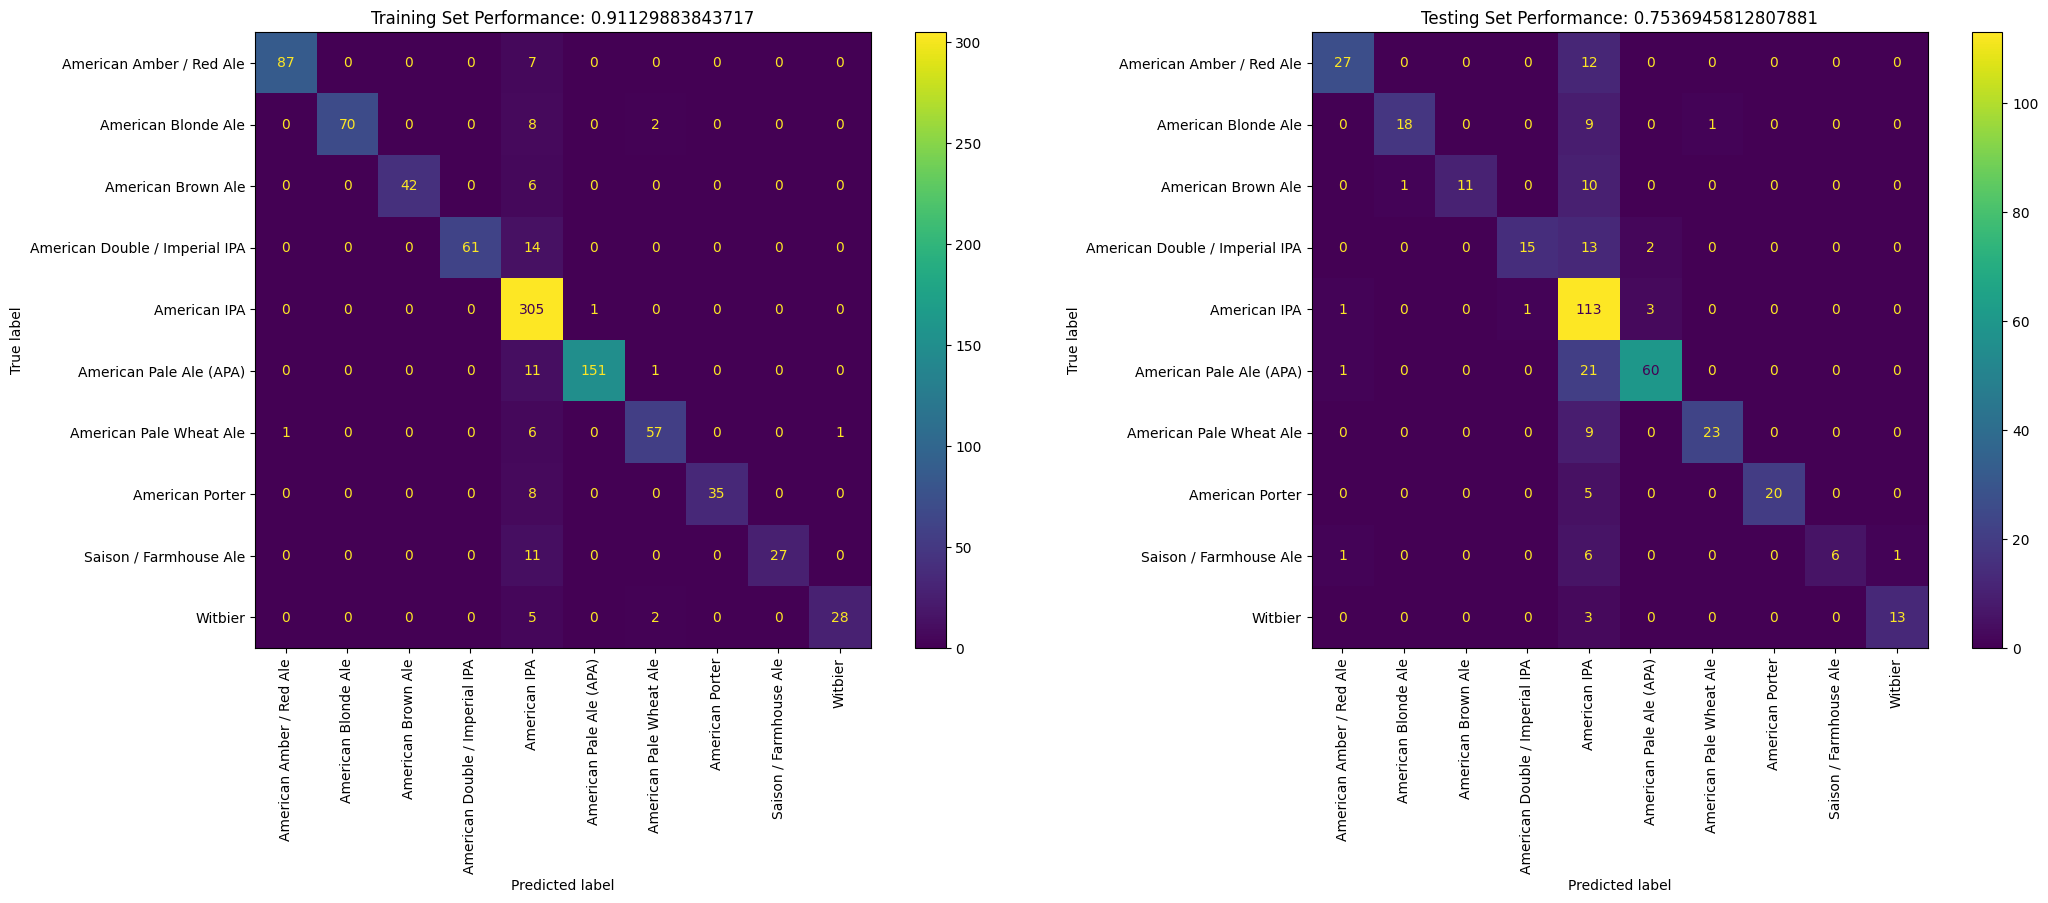

In [2]:
craft_beer = pandas.read_csv('../data/craft-cans/beers.csv')

# remove beers with no style or name
craft_beer = craft_beer[~craft_beer['style'].isna()]
craft_beer = craft_beer[~craft_beer['name'].isna()]
# make style a categorical
craft_beer['style'] = pandas.Categorical(craft_beer['style'])
counts = craft_beer['style'].value_counts()

# remove some beers that are rare
threshold = 50
to_remove = counts[counts <= threshold].index
# remove the beers, then remove the now unloved categories
craft_beer = craft_beer[~craft_beer['style'].isin(to_remove)]
craft_beer['style'] = craft_beer['style'].cat.remove_unused_categories()
craft_beer.reset_index(inplace=True)

# store as list of names
names = []
for n in craft_beer['name']:
    # strip out punctuation
    names.append(n.translate(str.maketrans('', '', string.punctuation)))

# split the data
X_train, X_test, Y_train, Y_test = train_test_split(names, craft_beer['style'], test_size=0.3, random_state=1)

# function to do our eval for us, this is quite simple and will
# - create a figure
# - draw a confusion matrix for the trainign data in a sub-fig on the left
# - draw a confusion matrix for the testing data in a sub-fig on the right
# - compute the overall classification accuracy on the testing data
# this has simply been created as we're going to do this for each test that we run
def eval_model(model, X_train, Y_train, X_test, Y_test):
    fig = plt.figure(figsize=[25, 8])
    ax = fig.add_subplot(1, 2, 1)
    conf = ConfusionMatrixDisplay.from_estimator(model, X_train, Y_train, normalize=None, xticks_rotation='vertical', ax=ax)
    pred = model.predict(X_train)
    conf.ax_.set_title('Training Set Performance: ' + str(sum(pred == Y_train)/len(Y_train)));
    ax = fig.add_subplot(1, 2, 2)
    conf = ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, normalize=None, xticks_rotation='vertical', ax=ax)
    pred = model.predict(X_test)
    conf.ax_.set_title('Testing Set Performance: ' + str(sum(pred == Y_test)/len(Y_test)));
    
# create Bag of Words encoding object
count_vect = CountVectorizer(min_df=0.0001, max_df=0.25)
# fit to training data, and apply to training data
X_train_counts = count_vect.fit_transform(X_train)
# apply to the test data
X_test_counts = count_vect.transform(X_test)

onevsone_svm = OneVsOneClassifier(SVC())
onevsone_svm.fit(X_train_counts, Y_train)
eval_model(onevsone_svm, X_train_counts, Y_train, X_test_counts, Y_test)

From the above, we've got our model working (if you're comparing performance between here and the classification example and wondering why it's slightly different, here we're not removing beer's with more than 6 words in their name, so the dataset is slightly bigger here). 

To re-use this model later on, we need to save two things:
* The bag of words model that's doing our feature transform
* The SVM that we've trained

Thankfully, SKLearn provides a simple way to save objects that works for just about all SKLearn classes. As per [https://scikit-learn.org/stable/model_persistence.html](https://scikit-learn.org/stable/model_persistence.html) there are a few options you have, but I'm going to recommend using the pickle library.

Using this, we can dump the two models to a pickle file as follows (note that I've imported dump above in the first code block):

In [3]:
with open("test_pickle_file.pkl", "wb") as f:
    dump(count_vect, f, protocol=5)
    dump(onevsone_svm, f, protocol=5)

One key detail to note here is that I've opened with file with `wb`, i.e. write-binary. 

If I wanted, I could dump each of these objects in their own pickle files, but as they two objects are very much designed to be used together (i.e. the feature transform used to train the model) I would argue that putting them in the one file makes sense.

To load these, I can then just use pickle's `load` function (again, this is imported above). Here, the file has been opened as `rb` (read-binary), and crtically I'm loading the items in the order that they were saved. Once I've got them loaded, I can use these objects just like I usually would, and I get identical performance to what I had above.

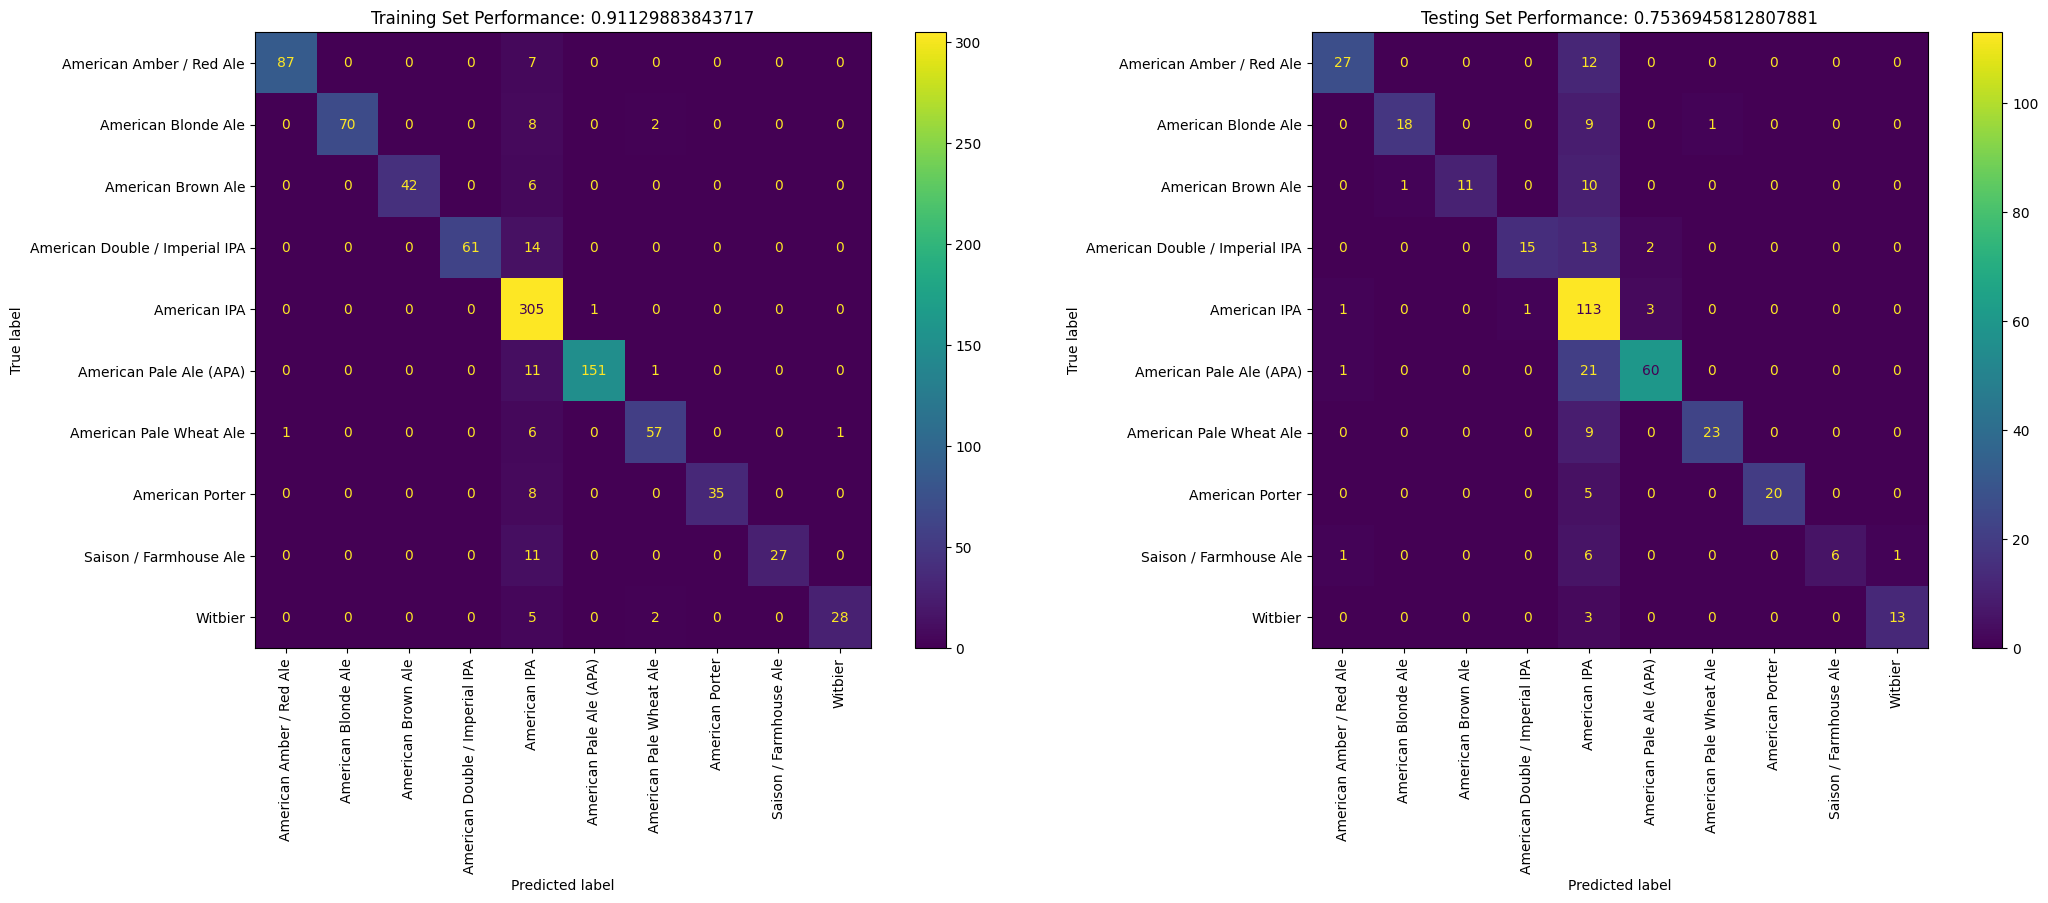

In [4]:
with open("test_pickle_file.pkl", "rb") as f:
    loaded_count_vect = load(f)
    loaded_onevsone_svm = load(f)

X_train_counts_loaded = loaded_count_vect.transform(X_train)
X_test_counts_loaded = loaded_count_vect.transform(X_test)
eval_model(loaded_onevsone_svm, X_train_counts_loaded, Y_train, X_test_counts_loaded, Y_test)

## Saving and Loading Keras Models

Let's now look at how we do the same thing with Keras. Here, I'm borrowing from `CAB420_DCNNs_Example_1_Classification_with_Deep_Learning.ipynb` and using one of the CNNs from there. Again, I'm going to gloss over a lot of details here, and if the below code for the model doesn't make sense, go back and check the main example.

One thing to note is that I've got code for setting mixed precision policies below (see [https://www.tensorflow.org/guide/mixed_precision](https://www.tensorflow.org/guide/mixed_precision) for more details). If you're uncertain what these do, comment them out. Note that you should only have one of these commented in depending on what hardware you are using.

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.7274 - loss: 0.7629 - val_accuracy: 0.8752 - val_loss: 0.3441
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.8661 - loss: 0.3691 - val_accuracy: 0.8872 - val_loss: 0.3023
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.8848 - loss: 0.3084 - val_accuracy: 0.8992 - val_loss: 0.2734
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.8976 - loss: 0.2796 - val_accuracy: 0.8699 - val_loss: 0.3972
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9074 - loss: 0.2521 - val_accuracy: 0.9055 - val_loss: 0.2561
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9167 - loss: 0.2302 - val_accuracy: 0.8985 - val_loss: 0.2663
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9192 - loss: 0.2179 - val_accuracy: 0.9070 - val_loss: 0.2614
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9261 - loss: 0.2001 - 

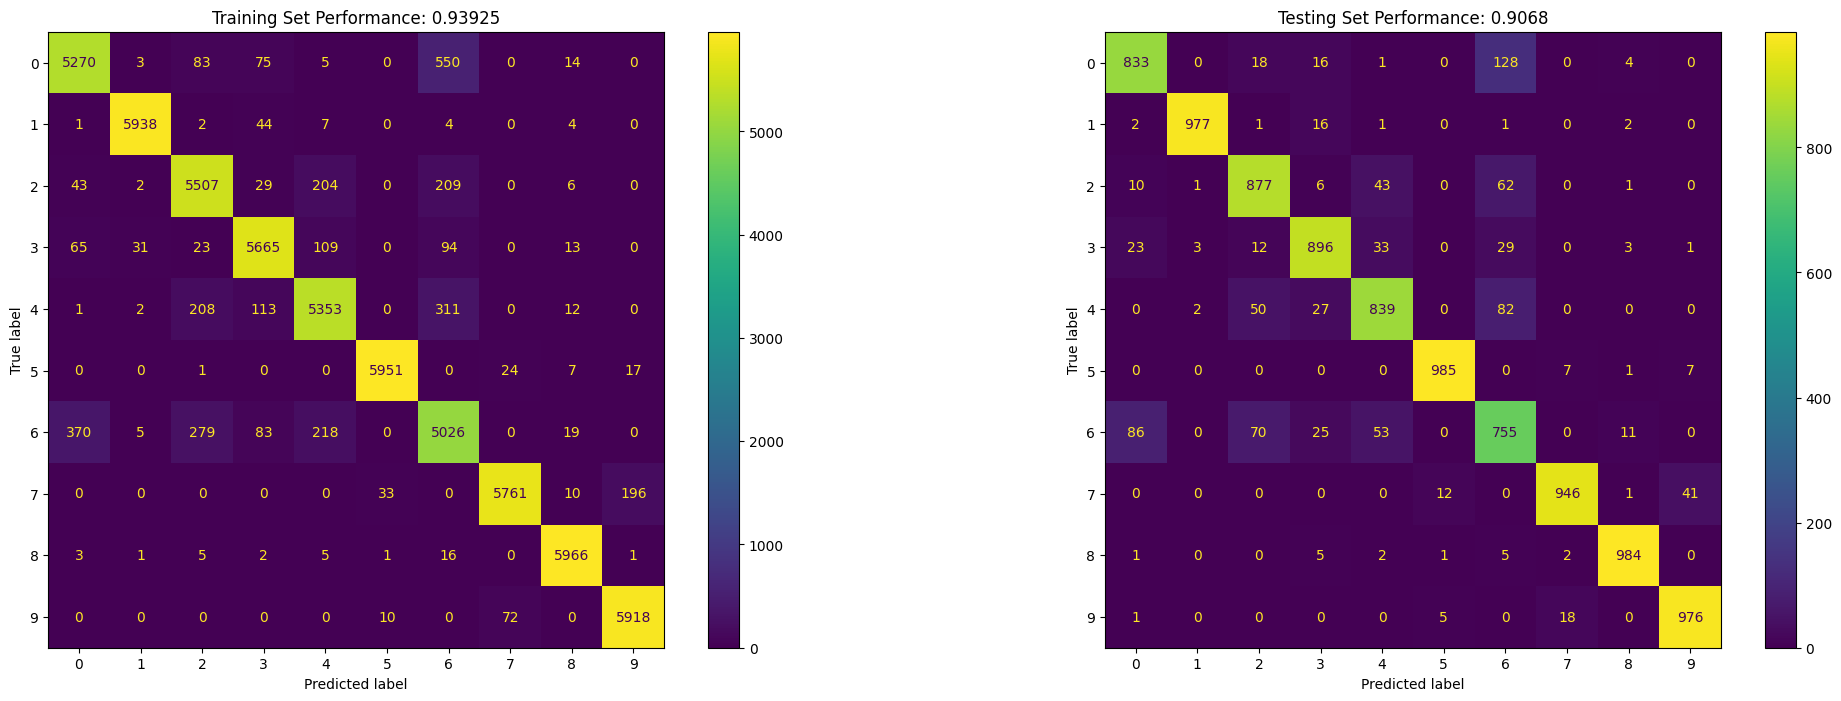

In [5]:
def eval_dl_model(model, x_train, y_train, x_test, y_test):

    fig = plt.figure(figsize=[25, 8])
    ax = fig.add_subplot(1, 2, 1)
    pred = model.predict(x_train, verbose=False);
    indexes = keras.ops.argmax(pred, axis=1).numpy()
    cm = confusion_matrix(y_train, indexes)
    c = ConfusionMatrixDisplay(cm, display_labels=range(10))
    c.plot(ax = ax)
    ax.set_title('Training Set Performance: ' + str(sum(indexes == y_train)/len(y_train)));

    ax = fig.add_subplot(1, 2, 2)
    pred = model.predict(x_test, verbose=False);
    indexes = keras.ops.argmax(pred, axis=1).numpy()
    cm = confusion_matrix(y_test, indexes)
    c = ConfusionMatrixDisplay(cm, display_labels=range(10))
    c.plot(ax = ax)
    ax.set_title('Testing Set Performance: ' + str(sum(indexes == y_test)/len(y_test)));

# enable mixed precision, this will improve training speed for little to no change in performance
#keras.mixed_precision.set_global_policy('mixed_float16')   # use this if you have a GPU
keras.mixed_precision.set_global_policy('mixed_bfloat16')   # use this if you have a CPU

# fashion-mnist
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

inputs = keras.Input(shape=(28, 28, 1, ), name='img')
# run pairs of conv layers, all 3s3 kernels
x = layers.Conv2D(filters=8, kernel_size=(3,3), padding='same', activation='relu')(inputs)
x = layers.Conv2D(filters=8, kernel_size=(3,3), padding='same', activation=None)(x)
# batch normalisation
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
# max pooling, 2x2, which will downsample the image
x = layers.MaxPool2D(pool_size=(2, 2))(x)

# rinse and repeat with 2D convs, batch norm and max pool
x = layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation='relu')(x)
x = layers.Conv2D(filters=16, kernel_size=(3,3), padding='same', activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)

# final conv2d and batch norm
x = layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
x = layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation=None)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
# flatten layer
x = layers.Flatten()(x)
# we'll use a couple of dense layers here, mainly so that we can show what another dropout layer looks like 
# in the middle
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
# the output
outputs = layers.Dense(10, activation=None)(x)

model_cnn = keras.Model(inputs=inputs, outputs=outputs, name='fashion_mnist_cnn_model')

model_cnn.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=keras.optimizers.AdamW(),
              metrics=['accuracy'], jit_compile=False)
history = model_cnn.fit(x_train, y_train,
                        batch_size=128, epochs=40, validation_split=0.2, 
                        callbacks=keras.callbacks.EarlyStopping(verbose=1, patience=3, restore_best_weights=True))

eval_dl_model(model_cnn, x_train, y_train, x_test, y_test)

Above, I've trained a model and it works ok. Saving models using keras is pretty simple, and there's a good guide at [https://keras.io/guides/serialization_and_saving/](https://keras.io/guides/serialization_and_saving/). Essentially, all I need to do is call the save function, and this will dump the entire model definition and all weights to a file.

In [6]:
model_cnn.save('test_model.keras')

Then to load the model, I can just the `keras.models.load_model` function, which will load up the full structure and all the weights. Then I can use this model like I would any other model.

One thing to note is that while this load process will load up the full structure and weights, other settings that configured by things like the `compile` function won't get pulled up properly. As such, if you're doing things like setting just in time compilation to false, you will need to do that again on the newly loaded model.

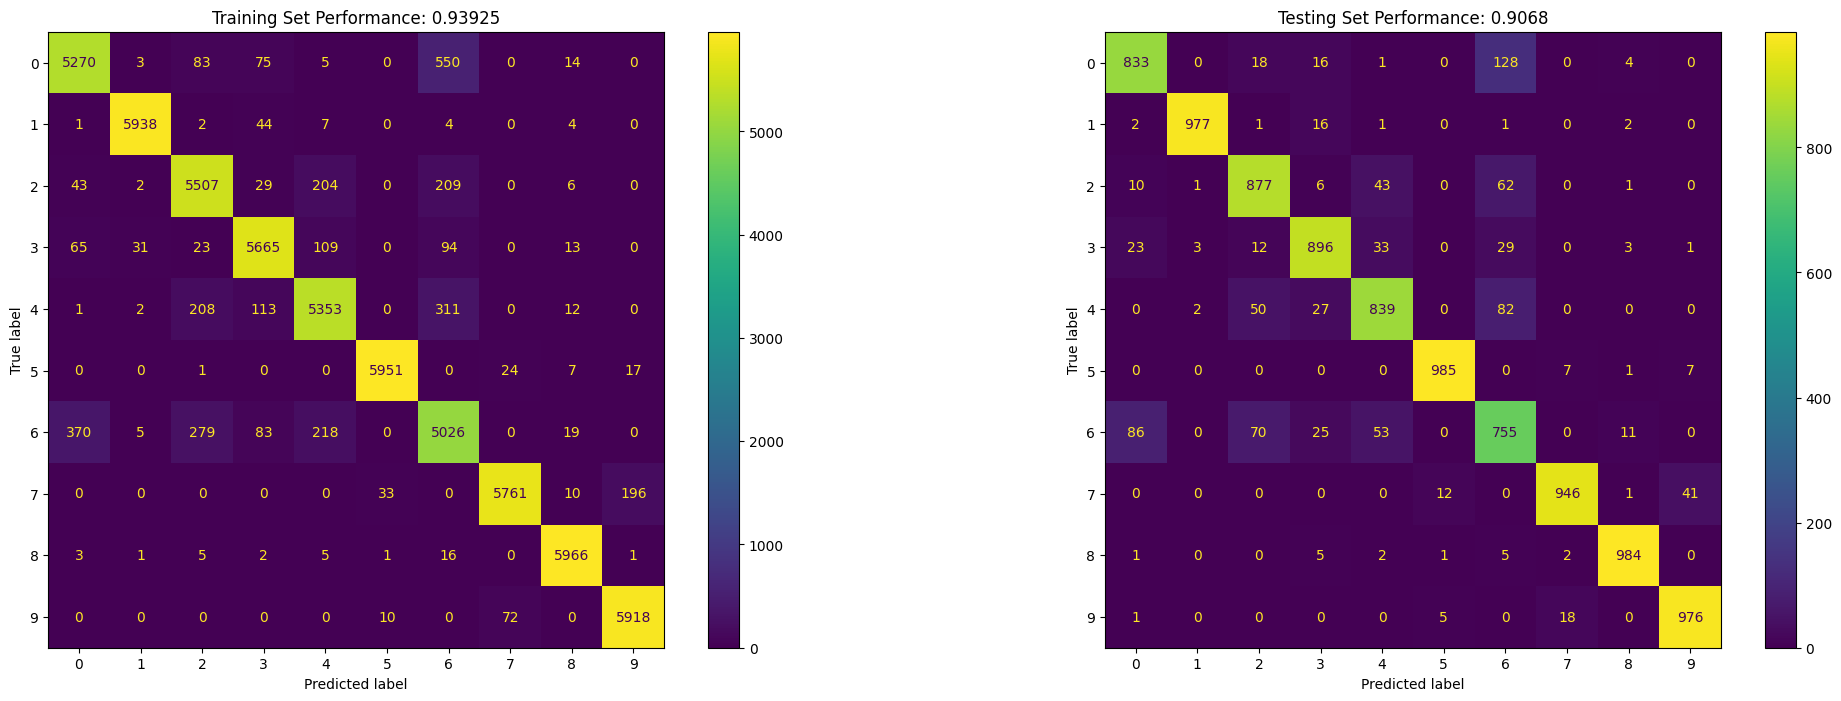

In [7]:
loaded_model_cnn = keras.models.load_model('test_model.keras')
model_cnn.compile(jit_compile=False)
eval_dl_model(loaded_model_cnn, x_train, y_train, x_test, y_test)